In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
def divided_difference_table(x, y):

    n = len(x)

    # Create an n x n table filled with zeros
    table = np.zeros((n, n))

    # Zeroth-order divided differences = function values
    table[:, 0] = y

    # Calculate higher-order divided differences
    for j in range(1, n):
        for i in range(n - j):

            table[i, j] = (
                table[i + 1, j - 1] - table[i, j - 1]
            ) / (x[i + j] - x[i])

    return table


# ---------------------------------------------------------
# Extract Newton coefficients
# ---------------------------------------------------------
def newton_coefficients(table):

    # First element of every divided-difference column
    return table[0, :]


# ---------------------------------------------------------
# Evaluate Newton interpolation polynomial
# ---------------------------------------------------------
def newton_interpolation(x_data, coefficients, x):

    n = len(coefficients)

    # Start with the highest-order coefficient
    result = coefficients[n - 1]

    # Evaluate using nested multiplication
    for i in range(n - 2, -1, -1):

        result = coefficients[i] + (x - x_data[i]) * result

    return result


In [6]:
x = np.array([-2, -1, 0, 1, 2], dtype=float)

# Function values
y = x**2 + 2*x + 1

In [8]:

# Construct divided-difference table
table = divided_difference_table(x, y)


# Extract Newton coefficients
coefficients = newton_coefficients(table)

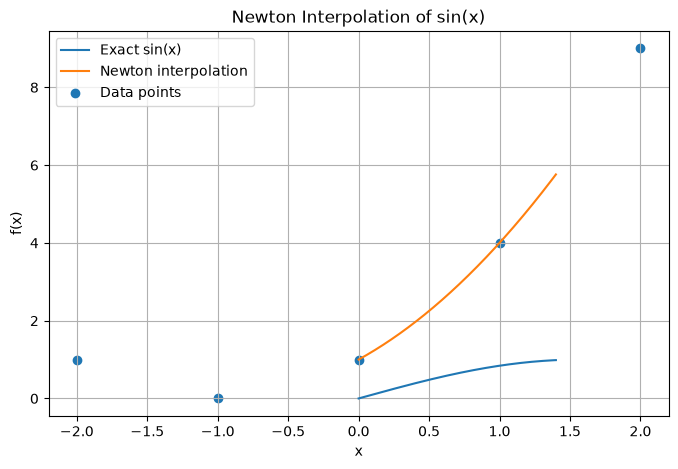

In [9]:


x_plot = np.linspace(0, 1.4, 500)

exact_values = np.sin(x_plot)

interpolated_values = np.array([
    newton_interpolation(x, coefficients, point)
    for point in x_plot
])


plt.figure(figsize=(8, 5))

plt.plot(
    x_plot,
    exact_values,
    label="Exact sin(x)"
)

plt.plot(
    x_plot,
    interpolated_values,
    label="Newton interpolation"
)

plt.scatter(
    x,
    y,
    label="Data points"
)

plt.xlabel("x")
plt.ylabel("f(x)")

plt.title("Newton Interpolation of sin(x)")

plt.legend()
plt.grid(True)

plt.show()

In [12]:
error = np.abs(
    exact_values - interpolated_values
)


In [13]:
max_error_index = np.argmax(error)

max_error = error[max_error_index]

max_error_x = x_plot[max_error_index]

print("\nMaximum interpolation error:")
print(f"Emax = {max_error:.10e}")
print(f"Occurs approximately at x = {max_error_x:.6f}")


Maximum interpolation error:
Emax = 2.0935112672e-04
Occurs approximately at x = 1.254108


Divided-Difference Table:
[[ 0.          0.99334665 -0.12287496 -0.14882138  0.02400436]
 [ 0.19866933  0.92576542 -0.27169635 -0.11521528  0.        ]
 [ 0.52268723  0.70840835 -0.40995469  0.          0.        ]
 [ 0.84147098  0.35994686  0.          0.          0.        ]
 [ 0.98544973  0.          0.          0.          0.        ]]

Newton Coefficients:
[ 0.          0.99334665 -0.12287496 -0.14882138  0.02400436]

Evaluation Results:
x		P4(x)		Exact sin(x)	Absolute Error
0.4		0.3894673523	0.3894183423	4.9010015934e-05
0.8		0.7172626697	0.7173560909	9.3421162543e-05
1.2		0.9322300290	0.9320390860	1.9094302214e-04


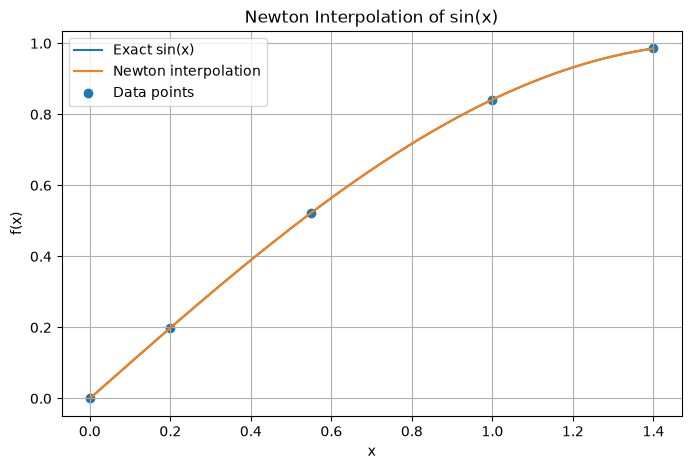

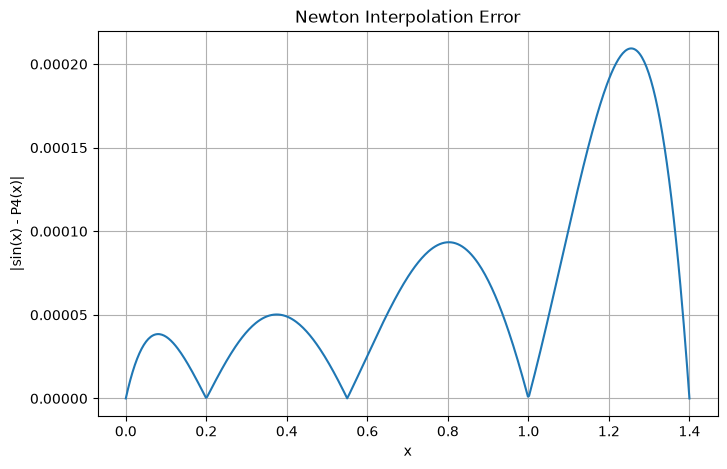


Maximum Error:
Emax = 2.0935112672e-04
Occurs approximately at x = 1.254108


In [15]:

def divided_difference_table(x, y):

    n = len(x)

    table = np.zeros((n, n))

    table[:, 0] = y

    for j in range(1, n):
        for i in range(n - j):

            table[i, j] = (
                table[i + 1, j - 1] - table[i, j - 1]
            ) / (x[i + j] - x[i])

    return table


def newton_coefficients(table):

    return table[0, :]

def newton_interpolation(x_data, coefficients, x):

    n = len(coefficients)

    result = coefficients[n - 1]

    for i in range(n - 2, -1, -1):

        result = coefficients[i] + (
            x - x_data[i]
        ) * result

    return result

x = np.array([
    0.0,
    0.2,
    0.55,
    1.0,
    1.4
])

# Function values
y = np.sin(x)

table = divided_difference_table(x, y)

print("Divided-Difference Table:")
print(table)


coefficients = newton_coefficients(table)

print("\nNewton Coefficients:")
print(coefficients)

evaluation_points = np.array([
    0.4,
    0.8,
    1.2
])


print("\nEvaluation Results:")
print(
    "x\t\tP4(x)\t\t"
    "Exact sin(x)\tAbsolute Error"
)


for point in evaluation_points:

    p_value = newton_interpolation(
        x,
        coefficients,
        point
    )

    exact_value = np.sin(point)

    error = abs(exact_value - p_value)

    print(
        f"{point:.1f}\t\t"
        f"{p_value:.10f}\t"
        f"{exact_value:.10f}\t"
        f"{error:.10e}"
    )

x_plot = np.linspace(0, 1.4, 500)

exact_values = np.sin(x_plot)

interpolated_values = np.array([
    newton_interpolation(
        x,
        coefficients,
        point
    )
    for point in x_plot
])

plt.figure(figsize=(8, 5))

plt.plot(
    x_plot,
    exact_values,
    label="Exact sin(x)"
)

plt.plot(
    x_plot,
    interpolated_values,
    label="Newton interpolation"
)

plt.scatter(
    x,
    y,
    label="Data points"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Newton Interpolation of sin(x)")
plt.legend()
plt.grid(True)

plt.show()

error = np.abs(
    exact_values - interpolated_values
)

plt.figure(figsize=(8, 5))

plt.plot(
    x_plot,
    error
)

plt.xlabel("x")
plt.ylabel("|sin(x) - P4(x)|")
plt.title("Newton Interpolation Error")
plt.grid(True)

plt.show()


# ---------------------------------------------------------
# Maximum error
# ---------------------------------------------------------

max_error_index = np.argmax(error)

max_error = error[max_error_index]

max_error_x = x_plot[max_error_index]

print("\nMaximum Error:")
print(f"Emax = {max_error:.10e}")
print(f"Occurs approximately at x = {max_error_x:.6f}")